# 階層式分群 (Hierarchical Clustering)

學習目標：
- 了解階層式分群和 K-means 的差異
- 學會畫樹狀圖（Dendrogram）
- 知道如何決定分幾群

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

## 1. K-means vs 階層式分群

K-means：
- 需要事先指定 K
- 適合大資料集
- 結果是圓形群體

階層式分群：
- 不需要事先指定 K
- 適合小資料集
- 結果是樹狀結構（可以事後決定切幾群）
- 可以看出群體之間的關係

In [2]:
# 建立運動員資料（三個自然群體）
np.random.seed(42)

elite    = np.random.randn(20, 2) + [8, 8]
medium   = np.random.randn(25, 2) + [4, 4]
beginner = np.random.randn(20, 2) + [1, 1]

X = np.vstack([elite, medium, beginner])
true_labels = ['菁英']*20 + ['中等']*25 + ['新手']*20

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'總資料筆數：{len(X)}')

總資料筆數：65


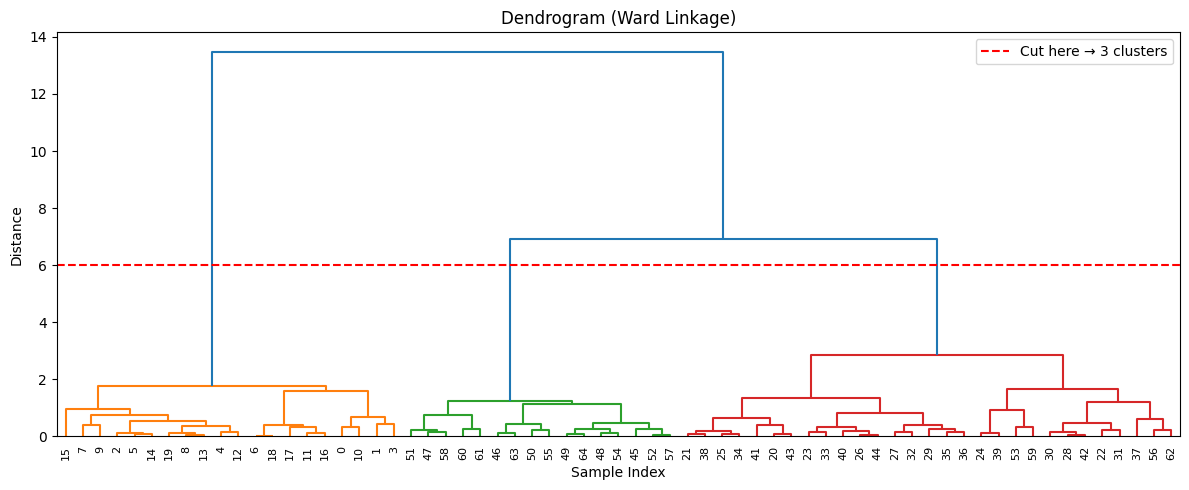

In [4]:
# 計算連結矩陣（Ward 方法）
Z = linkage(X_scaled, method='ward')

# 畫樹狀圖
plt.figure(figsize=(12, 5))
dendrogram(Z, leaf_rotation=90,
           leaf_font_size=8,
           color_threshold=6)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=6, color='red', linestyle='--',
            label='Cut here → 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()

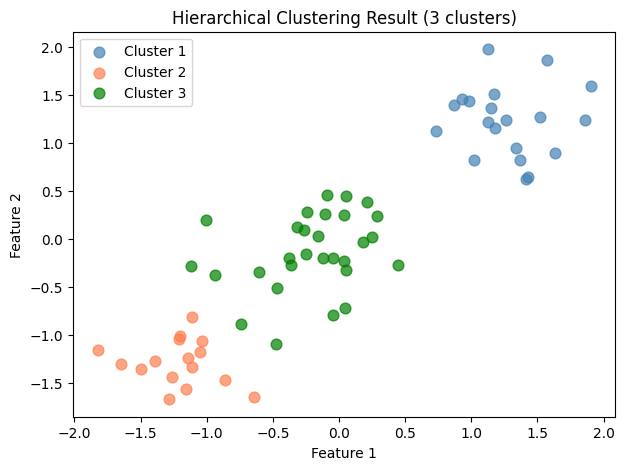

In [5]:
# 根據樹狀圖切成3群
cluster_labels = fcluster(Z, t=3, criterion='maxclust')

# 視覺化分群結果
colors = ['steelblue', 'coral', 'green']
plt.figure(figsize=(7, 5))
for i in range(1, 4):
    mask = cluster_labels == i
    plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                color=colors[i-1], alpha=0.7, s=60,
                label=f'Cluster {i}')

plt.title('Hierarchical Clustering Result (3 clusters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

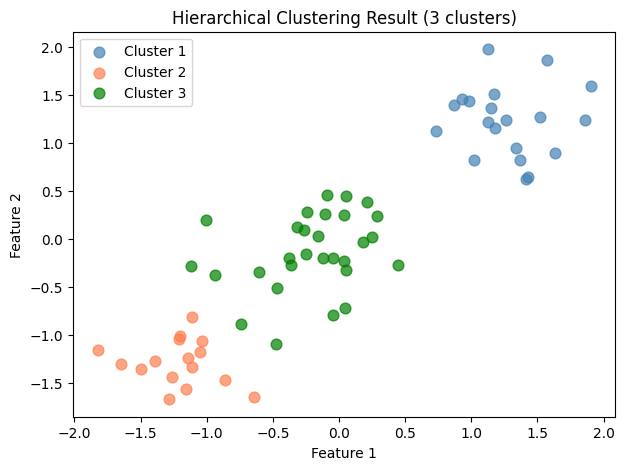

In [6]:
# 根據樹狀圖切成3群
cluster_labels = fcluster(Z, t=3, criterion='maxclust')

# 視覺化分群結果
colors = ['steelblue', 'coral', 'green']
plt.figure(figsize=(7, 5))
for i in range(1, 4):
    mask = cluster_labels == i
    plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                color=colors[i-1], alpha=0.7, s=60,
                label=f'Cluster {i}')

plt.title('Hierarchical Clustering Result (3 clusters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [7]:
# 比較 K-means vs 階層式分群
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

hier = AgglomerativeClustering(n_clusters=3)
hier_labels = hier.fit_predict(X_scaled)

km_score   = silhouette_score(X_scaled, kmeans_labels)
hier_score = silhouette_score(X_scaled, hier_labels)

print(f'{"方法":<12} {"Silhouette Score":>18}')
print('-' * 32)
print(f'{"K-means":<12} {km_score:>18.3f}')
print(f'{"階層式分群":<12} {hier_score:>18.3f}')

方法             Silhouette Score
--------------------------------
K-means                   0.613
階層式分群                     0.598


## 2. 我的學習筆記

1. 這個主題在做什麼：
   用樹狀結構呈現資料的分群過程，
   可以從樹狀圖直觀看出群體間的距離關係，
   事後再決定要切幾群。

2. 樹狀圖怎麼看：
   - 縱軸高度 = 兩群合併時的距離
   - 紅線切的位置 = 決定分幾群
   - 切越高 = 群數越少

3. 我覺得最難理解的地方：
   蠻難的
   

4. 這個跟我研究的連結：
   分析不同運動項目的選才標準時，
   用階層式分群可以看出哪些運動項目
   對選手要求最相似，哪些差異最大，
   幫助建立更細緻的分類模型。